In [2]:
import os
import numpy as np
import torch
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import pickle
helpers_path = os.path.join('/ether/aegis/Research_HEP/NRAD/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

In [3]:
# Load Train Data
# data_events = np.load(f"/home/aegis/ether/Research_HEP/NRAD/SemiVisJets/data/data_test/data_events_chunk{6:02d}.npz", allow_pickle=True)
# Load Test Data

# Paths
model_path = "/home/aegis/ether/Research_HEP/NRAD/SemiVisJets/eval_sr"
samples_path = "/home/aegis/ether/Research_HEP/NRAD/SemiVisJets/samples"
mc_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/data"
scaler_path = "/ether/aegis/Research_HEP/NRAD/SemiVisJets/mc_scalers"
signal_path = "/ether/aegis/Research_HEP/NRAD/Signal/processed_signal"

In [4]:
model_pt = os.listdir(model_path)

model_dict_pt = {}

for model in ["reweight", "generate"]:
    for data in range(1, 6):
        model_dict_pt[f"{model}_Data{data:02d}_MC02"] = []

for pt in model_pt:
    # print(pt)
    if pt in ["auc_scores", "loss_data"]:
        continue
    model = pt.split("_")[1]
    data_ver = pt.split("_")[3]
    mc_ver = pt.split("_")[4]
    run = pt.split("_")[5].replace(".pt", "").replace("run", "")

    # print(model, data_ver, mc_ver, run)
    model_dict_pt[f"{model}_{data_ver}_{mc_ver}"].append(pt)


In [12]:
var_names = ["ht", "met", "m_jj", "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2"]

with open(f"{scaler_path}/mc_scaler_chunk03.pkl","rb") as f:
    mc_scaler = pickle.load(f)


signal_samples = {}
signal_modes = ["1000_2", "1000_4", "1000_6", "1000_8", "2000_2", "2000_4", "2000_6", "2000_8", "3000_2", "3000_4", "3000_6", "3000_8"]

# Import signal samples
all_columns = [
    "pT_j1", "eta_j1", "phi_j1",
    "pT_j2", "eta_j2", "phi_j2",
    "m_jj", "tau21_j1", "tau21_j2",
    "tau32_j1", "tau32_j2",
    "met", "phi_met", "min_dPhi", "ht"
]

def sr_mask(events):
    ht = events[:,0]
    met = events[:,1]
    # Apply SR cuts
    mask = (ht > 600) & (met > 600)
    return mask
# Find indices of desired variables
cols_to_use = [all_columns.index(v) for v in var_names]

for mode in signal_modes:
    signal_data = np.loadtxt(f"{signal_path}/{mode}_events.txt", skiprows=1, usecols=cols_to_use)
    # print(signal_data)
    sig_mask = sr_mask(signal_data)

    signal_samples[mode] = mc_scaler.transform(signal_data[sig_mask])
    # signal_samples[mode] = signal_data
    print(f"Loaded signal mode {mode} with shape: {signal_data.shape}")

Loaded signal mode 1000_2 with shape: (5347, 7)
Loaded signal mode 1000_4 with shape: (6237, 7)
Loaded signal mode 1000_6 with shape: (6997, 7)
Loaded signal mode 1000_8 with shape: (7801, 7)
Loaded signal mode 2000_2 with shape: (3968, 7)
Loaded signal mode 2000_4 with shape: (4717, 7)
Loaded signal mode 2000_6 with shape: (5466, 7)
Loaded signal mode 2000_8 with shape: (6093, 7)
Loaded signal mode 3000_2 with shape: (1769, 7)
Loaded signal mode 3000_4 with shape: (2123, 7)
Loaded signal mode 3000_6 with shape: (2405, 7)
Loaded signal mode 3000_8 with shape: (2847, 7)


In [13]:
data_events = signal_samples["1000_2"]
background_events = np.load(f"{mc_path}/mc_events_chunk03.npz", allow_pickle=True)
background_events = background_events["mc_events_sr"]
print(data_events.shape)
print(background_events.shape)

(23, 7)
(46968, 7)


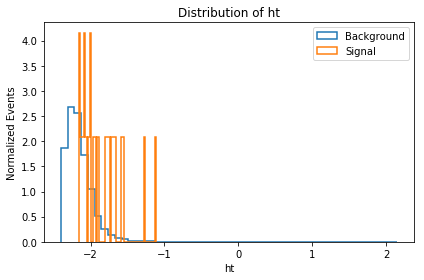

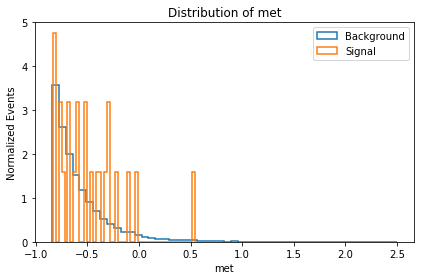

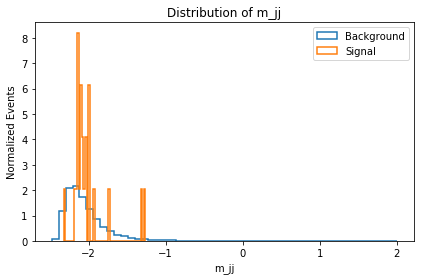

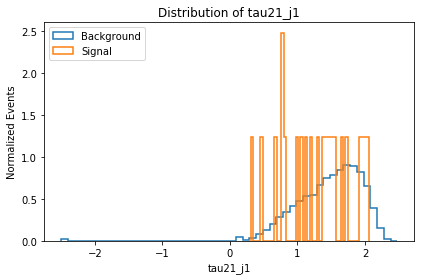

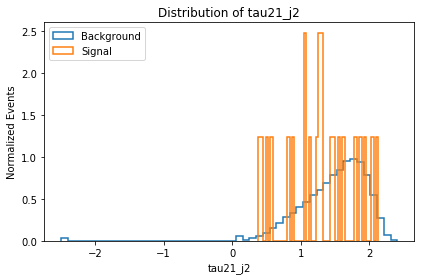

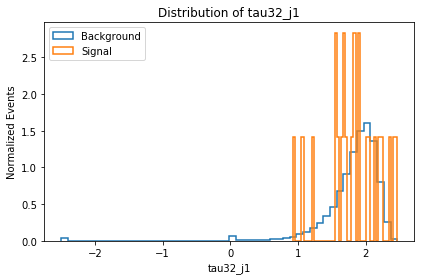

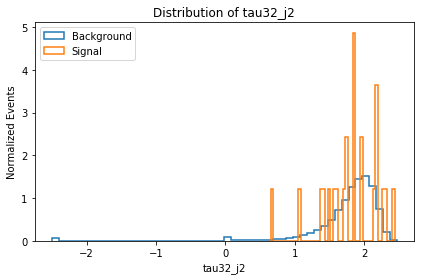

In [14]:
# --- Create plotting dictionary (column index -> variable name) ---
plot_dict = {name: (data_events[:, i], background_events[:, i]) for i, name in enumerate(var_names)}

# --- Plot distributions ---
for var, (sig, bkg) in plot_dict.items():
    plt.figure(figsize=(6,4))
    plt.hist(bkg, bins=50, density=True, histtype='step', label='Background', linewidth=1.5)
    plt.hist(sig, bins=50, density=True, histtype='step', label='Signal', linewidth=1.5)
    plt.xlabel(var)
    plt.ylabel("Normalized Events")
    plt.legend()
    plt.title(f"Distribution of {var}")
    plt.tight_layout()
    plt.show()

(46991, 5) (46991,)


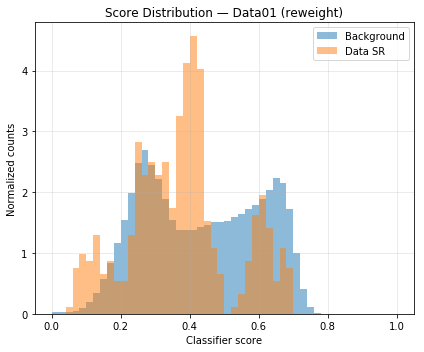

(46991, 5) (46991,)


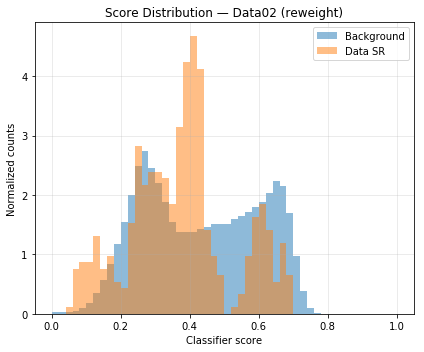

(46991, 5) (46991,)


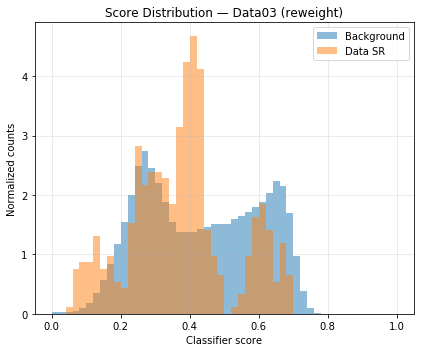

(46991, 5) (46991,)


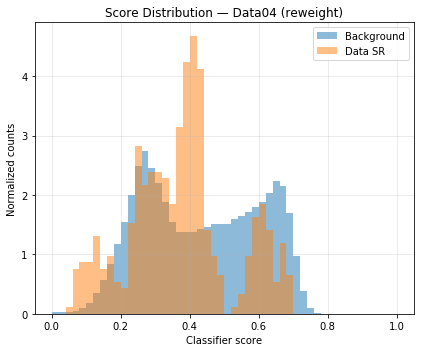

(46991, 5) (46991,)


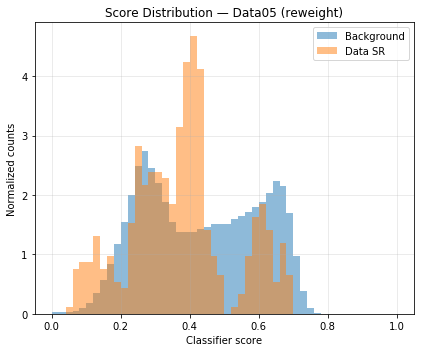

In [15]:
# Evaluate Reweight
model = "reweight"
seed = 2
n_context = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for i in range(1, 6):
    data_ver = f"Data{i:02d}"
    # reweights_events = np.load(f"{samples_path}/reweight_MC{seed:02d}_{data_ver}_SR_samples.npz", allow_pickle=True)
    reweights_events = np.load(f"{mc_path}/mc_events_chunk03.npz", allow_pickle=True)
    
    background_samples = reweights_events["mc_events_sr"][:, n_context:]
    # data_events_sr = data_events["data_events_sr"][:, n_context:]
    data_events_sr = data_events[:, n_context:]
    
    input_x_test = np.concatenate([background_samples, data_events_sr], axis = 0)
    input_y_test = np.concatenate([np.zeros(background_samples.shape[0]).reshape(-1, 1), np.ones(data_events_sr.shape[0]).reshape(-1, 1)], axis = 0)
    input_y_test = np.squeeze(input_y_test)
    print(input_x_test.shape, input_y_test.shape)
    # import model
    scores_to_ensemble = []
    all_scores_bkg = []
    all_scores_data = []
    for run in model_dict_pt[f"{model}_{data_ver}_MC02"]:
        run_num = run.split("_")[5].replace(".pt", "").replace("run", "")
        # print(run_num)

        NN = torch.load(f"{model_path}/{run}", map_location=device, weights_only=False)
        # NN.to(device)
        # NN.model.eval()

        scores = NN.evaluation(input_x_test)
        # plt.plot(scores)
        # plt.show()
        # print(scores.shape)
        scores_to_ensemble.append(scores)
        scores = np.squeeze(scores)

        all_scores_data.extend(scores[input_y_test == 1])
        all_scores_bkg.extend(scores[input_y_test == 0])

    avg_scores = np.mean(scores_to_ensemble, axis = 0)
    
    # -----------------------------
    # 📊 Plot Score Distributions
    # -----------------------------
    plt.figure(figsize=(6, 5))
    plt.hist(all_scores_bkg, bins=50, range=(0, 1), histtype='stepfilled',
                alpha=0.5, color='tab:blue', label='Background', density=True)
    plt.hist(all_scores_data, bins=50, range=(0, 1), histtype='stepfilled',
                alpha=0.5, color='tab:orange', label='Data SR', density=True)
    plt.xlabel("Classifier score")
    plt.ylabel("Normalized counts")
    plt.title(f"Score Distribution — {data_ver} ({model})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    # plt.savefig(f"{output_dir}/scores_{dataset}_{mode}.png", dpi=150)
    plt.show()
    plt.close()


(46991, 5) (46991,)


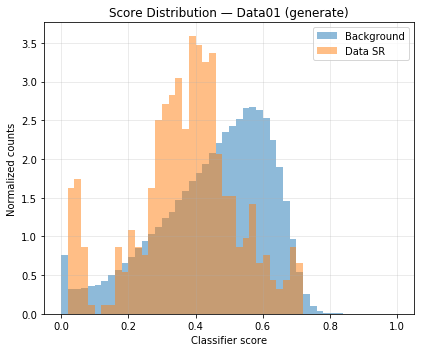

(46991, 5) (46991,)


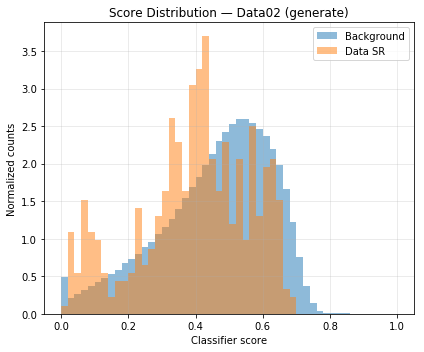

(46991, 5) (46991,)


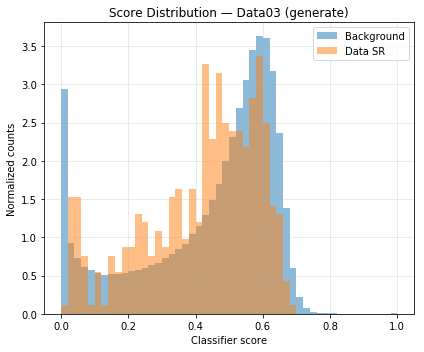

(46991, 5) (46991,)


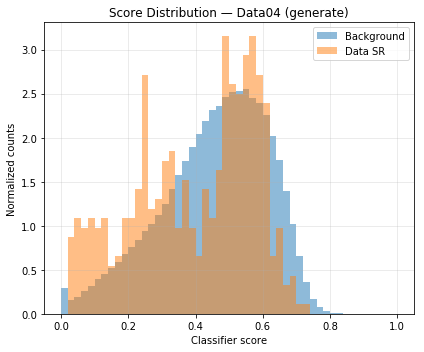

(46991, 5) (46991,)


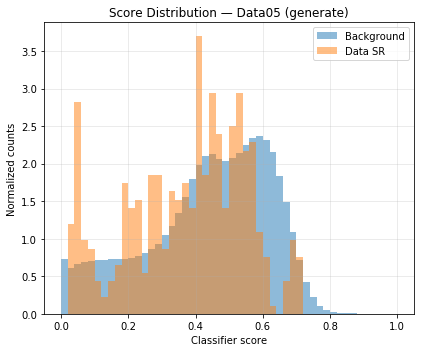

In [16]:
# Evaluate Reweight
model = "generate"
seed = 2
n_context = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for i in range(1, 6):
    data_ver = f"Data{i:02d}"
    generate_events = np.load(f"{samples_path}/{model}_MC{seed:02d}_{data_ver}_SR_samples.npz", allow_pickle=True)
    
    background_samples = generate_events["samples"]
    # data_events_sr = data_events["data_events_sr"][:, n_context:]
    data_events_sr = data_events[:, n_context:]

    input_x_test = np.concatenate([background_samples, data_events_sr], axis = 0)
    input_y_test = np.concatenate([np.zeros(background_samples.shape[0]).reshape(-1, 1), np.ones(data_events_sr.shape[0]).reshape(-1, 1)], axis = 0)
    input_y_test = np.squeeze(input_y_test)
    print(input_x_test.shape, input_y_test.shape)
    # import model
    scores_to_ensemble = []
    all_scores_bkg = []
    all_scores_data = []
    for run in model_dict_pt[f"{model}_{data_ver}_MC02"]:
        run_num = run.split("_")[5].replace(".pt", "").replace("run", "")
        # print(run_num)

        NN = torch.load(f"{model_path}/{run}", map_location=device, weights_only=False)
        # NN.to(device)
        # NN.model.eval()

        scores = NN.evaluation(input_x_test)
        # plt.plot(scores)
        # plt.show()
        # print(scores.shape)
        scores_to_ensemble.append(scores)
        scores = np.squeeze(scores)

        all_scores_data.extend(scores[input_y_test == 1])
        all_scores_bkg.extend(scores[input_y_test == 0])

    avg_scores = np.mean(scores_to_ensemble, axis = 0)
    
    # -----------------------------
    # 📊 Plot Score Distributions
    # -----------------------------
    plt.figure(figsize=(6, 5))
    plt.hist(all_scores_bkg, bins=50, range=(0, 1), histtype='stepfilled',
                alpha=0.5, color='tab:blue', label='Background', density=True)
    plt.hist(all_scores_data, bins=50, range=(0, 1), histtype='stepfilled',
                alpha=0.5, color='tab:orange', label='Data SR', density=True)
    plt.xlabel("Classifier score")
    plt.ylabel("Normalized counts")
    plt.title(f"Score Distribution — {data_ver} ({model})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    # plt.savefig(f"{output_dir}/scores_{dataset}_{mode}.png", dpi=150)
    plt.show()
    plt.close()
